In [2]:

# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import write, read
from IPython.display import Audio
import IPython

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import sawtooth, square
from IPython.display import Audio, HTML
    
%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

import soundfile as sf
from urllib.request import urlopen
import io

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")




In [3]:
# load relevant modules from header file

###############################################################################
# FM parameters

 
f_car       = 100  # carrier frequency
f_mod       = 3000 # signal frequency
 
mod_ind     = 10
 

###############################################################################
# function for FM with outputs for carrier and modulator

def fm(f_car, f_mod, m, t):
 
    x_car = np.sin(2*np.pi*f_car*t)
    x_mod = np.sin(2*np.pi*f_mod*t)#


    y = np.sin(2*np.pi*f_car*t+ m * x_mod)
    
    return [y, x_car, x_mod]

 
###############################################################################
# axis and signals

fs  = 16000
d   = 1
L   = round(d*fs)

t   = np.linspace(0,d,L)    
f   = np.linspace(-0.5,0.5,L)
 
    


# FM Equation

Frequency modulation with two sinusoidal oscillators 
can be written as follows:

$$
x(t) = A \sin(2 \pi f_c t + I \sin(2 \pi f_m t) )
$$

The modulation index $I$ determins the strength of the modulation effect,
relative to the modulator frequency.
It can be expressed as:

$$I = \frac{\Delta f}{\Delta f_m}$$

---


# Spectrum of Frequency Modulation

Compared to amplitude modulation techniques, FM generates more - as in **infinite** - spectral components, which 
can be illustrated when calculating the Fourier transform of the FM formula:

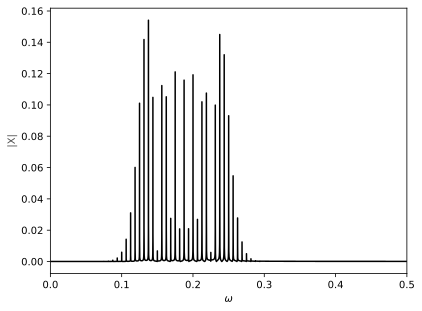

In [4]:
# in the frequency domain

 
[x, x_car, x_sig] = fm(f_mod, f_car, mod_ind, t)
 
# fft stuff   
X = np.fft.fftshift(np.fft.fft(x))
X = X/(L)

X_car = np.fft.fftshift(np.fft.fft(x_car))
X_car = X_car/(L)

X_sig = np.fft.fftshift(np.fft.fft(x_sig))
X_sig = X_sig/(L)


fig1, ax1 = plt.subplots()
 
ax1.set_xlabel('$\omega$')
ax1.set_ylabel('|X|' ,color = [ 0.3, 0.3, 0.3])
ax1.set_xlim(0, 0.5) 

# for static HTML output:
line, = ax1.plot(f,abs(X), 'k');
 







Based on the FM formula, the spectrum can be calculated  using trigonometric identities:



$$
x(t)   =   \cos(\omega_\alpha t + I \sin(\omega_\beta t) )
$$

$\textbf{with:} \cos(a+b) = \cos(a) \cos(b) - \sin(a) \sin(b)$

$$
x(t) = \cos(\omega_\alpha t) \cos(I \sin(\omega_\beta t)) - \sin(\omega_\alpha t) \sin(I \sin(\omega_\beta t))
$$

$\textbf{With:} \cos(a) \cos(b) = \frac{1}{2} \left( \cos(a-b) + \cos(a+b) \right)$

$\textbf{And:} \sin(a) \sin(b) = \frac{1}{2} \left( \cos(a-b) - \cos(a+b) \right)$

$$
\begin{eqnarray}
&=&  \frac{1}{2} (
\sin(\omega_\alpha t + I \sin(\omega_\alpha t)) \\
&&+ \sin(\omega_\alpha t - I \sin(\omega_\alpha t))\\
&&+ \sin(\omega_\alpha t + I \sin(\omega_\alpha t)) \\
&&+ \sin( I \sin(\omega_\alpha t) - \omega_\alpha t) )
\end{eqnarray}
$$


----

 
## Bessel functions

The Fourier transform of the equation above can be expressed through a series of delta impulses, with amplitudes being derived from Bessel functions $J_n$: 
 
$$X(f) = \sum_{n = -\infty}^{\infty} J_n^2(\beta) \delta(f - f_c - n f_m)$$ 
 
Since this series is infinite, **the spectrum of FM signals has an infinite number 
of sidebands** which are increased in energy for high modulation indices.
 
 
-----

### Bessel Functions of first Kind
 

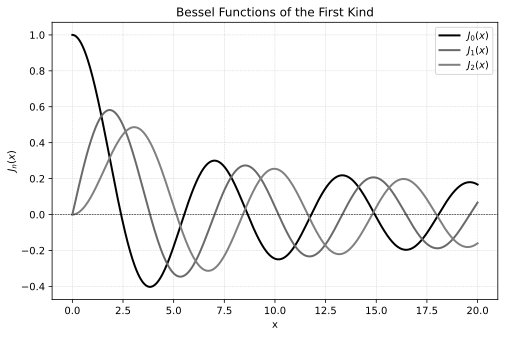

In [5]:
from scipy.special import jn

# Define the range for x values
x = np.linspace(0, 20, 500)

# Compute Bessel function of the first kind for order n=0, 1, 2
J0 = jn(0, x)
J1 = jn(1, x)
J2 = jn(2, x)

# Grayscale color scheme
grayscale_colors = ['black', 'dimgray', 'gray']

# Plot the Bessel functions
plt.figure(figsize=(8, 5))
plt.plot(x, J0, label=r'$J_0(x)$', linewidth=2, color=grayscale_colors[0])
plt.plot(x, J1, label=r'$J_1(x)$', linewidth=2, color=grayscale_colors[1])
plt.plot(x, J2, label=r'$J_2(x)$', linewidth=2, color=grayscale_colors[2])

# Labels and title
plt.xlabel('x')
plt.ylabel(r'$J_n(x)$')
plt.title('Bessel Functions of the First Kind')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='lightgray')

# Show the plot
plt.show()

---


## Harmonic vs Inharmonic

Depending on the ratio between modulator and carrier, the FM spectrum has different properties.
In the formula for the FM sidebands is is obvious that for integer ratios between carrier to modulator,
all sidebands are integer multiples of the fundamental frequency.